In [25]:
from abc import ABC, abstractmethod
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
class Layer(ABC):
    
    @abstractmethod
    def forward(self, input):
        ...
    
    @abstractmethod
    def backward(self, gradient):
        ...
    
    @abstractmethod
    def update(self, lr):
        ...


In [27]:
class Loss(ABC):
    
    @abstractmethod
    def forward(self, target, preficted):
        ...
    
    @abstractmethod
    def backward(self, target, predicted):
        ...


In [31]:
class MSE(Loss):
    
    @staticmethod
    def forward(target, predicted):
        return np.sum(np.square(predicted - target)) / (target.shape[0] * target.shape[1])
    
    @staticmethod
    def backward(target, predicted):
        return 2 * (predicted - target) / (target.shape[0] * target.shape[1])



In [28]:
class Dense(Layer):
    
    def __init__(self, in_features, out_features):
        super().__init__()
        
        self.in_features = in_features
        self.out_features = out_features
        
        # He initialization
        # self.weights = np.random.randn(in_features, out_features) * np.sqrt(2 / in_features)
        #Xavier
        self.weights = np.random.randn(in_features, out_features) * np.sqrt(2/ (in_features + out_features))
        self.biases = np.zeros(out_features)
    
    def forward(self, input):
        self.input = input
        return input @ self.weights + self.biases
    
    def backward(self, dZ):
        self.dweights = self.input.T @ dZ
        self.dbiases = np.sum(dZ, axis=0)
        return dZ @ self.weights.T
    
    def update(self, lr):
        self.weights -= lr * self.dweights
        self.biases -= lr * self.dbiases


In [60]:
class Sigmoid(Layer):
    
    def forward(self, input):
        self.value = 1 / (1 + np.exp(-1 * input))
        return self.value
    
    def backward(self, dA):
        return dA * (self.value * (1 - self.value))
    
    def update(self, lr):
        pass

In [30]:
class ReLU(Layer):
    
    def forward(self, input):
        self.mask = input > 0
        return np.maximum(0, input)
    
    def backward(self, dA):
        return dA * self.mask
    
    def update(self, lr):
        pass

In [32]:
class Network():
    
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, gradient):
        for layer in reversed(self.layers):
            gradient = layer.backward(gradient)

    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)



Loss: 0.24964249382491682
Prediction:
[[0.47183081]
 [0.4669518 ]
 [0.46665298]
 [0.46986549]
 [0.47206427]
 [0.47148773]
 [0.46745565]
 [0.47149355]
 [0.46803316]
 [0.47304343]
 [0.46898676]
 [0.46971656]
 [0.47114436]
 [0.46935168]
 [0.46868238]
 [0.47010716]
 [0.47071104]
 [0.46707276]
 [0.46928559]
 [0.46919094]]
Predicted classes:
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]
Real classes:
[[1]
 [2]
 [1]
 [1]
 [1]
 [1]
 [2]
 [1]
 [1]
 [1]
 [1]
 [1]
 [2]
 [2]
 [1]
 [1]
 [1]
 [2]
 [1]
 [1]]


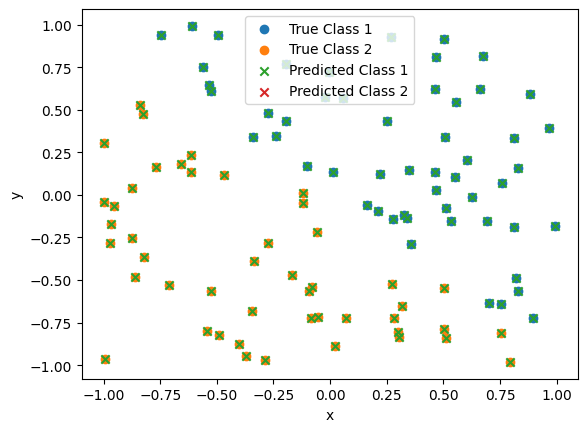

Weights:
[[ 0.11767441  0.18594646 -0.14133001 -0.12001189 -0.11389993  0.1991207
  -0.02255829 -0.00561797 -0.04781196  0.21080694 -0.05499759 -0.17547599
   0.11323679 -0.01428632  0.04018523 -0.01594987 -0.19324276  0.06267046
  -0.26843176  0.15016415 -0.02172885 -0.13463427  0.05126876  0.05989984
  -0.05314974  0.14543654  0.26921811  0.03647901  0.02198545 -0.05953672
   0.05703256  0.21105182 -0.18545138  0.24025975  0.14182949 -0.0293864
  -0.02551646  0.0127062  -0.00283107 -0.16679235  0.12840295  0.07307623
   0.08361139 -0.13423409  0.07622546 -0.05512387 -0.21609966  0.04593479
  -0.15470121  0.04240187 -0.02551236  0.09068636  0.06350893  0.19347201
   0.14391203 -0.21644331  0.03480014  0.03282402 -0.12057482  0.04505363
   0.05540857 -0.15051911  0.14107485  0.00514366  0.06814092 -0.04600856
   0.2365709   0.13110621  0.20331539  0.03159788  0.062244   -0.09075135
  -0.11680179  0.1048293  -0.31983216  0.09846872 -0.16503563  0.01405337
   0.19457697 -0.17103163  0.05

In [61]:
per = Network(
    [
        Dense(2, 128),
        Sigmoid(),
        Dense(128, 128),
        Sigmoid(),
        Dense(128, 1),
        Sigmoid(),
    ]
)

df = pd.read_csv("data.simple.train.100.csv")

n = 20
epochs = 500

list_df = [df[i:i + n] for i in range(0, df.shape[0], n)]

for epoch in range(epochs):
    for batch in list_df:

        # # changing class to values 0 or 1
        target = (batch.iloc[:, -1:].to_numpy() - 1)

        inputs = batch.iloc[:, :2].to_numpy()

        pred = per.forward(inputs)

        loss = MSE.forward(target, pred)

        gradient = MSE.backward(target, pred)

        per.backward(gradient)

        per.update(0.001)


df = pd.read_csv("data.simple.test.100.csv")

inputs = df.iloc[:, :2].to_numpy()

target = df.iloc[:, -1:].to_numpy()

# changing class to values 0 or 1
target_binary = target - 1


pred = per.forward(inputs)

loss = MSE.forward(target_binary, pred)

pred_class = np.where(pred >= 0.5, 2, 1)


print("Loss:", loss)
print("Prediction:")
print(pred[:20])

print("Predicted classes:")
print(pred_class[:20])

print("Real classes:")
print(target[:20])


x = df.iloc[:, 0].to_numpy()
y = df.iloc[:, 1].to_numpy()


plt.scatter(
    x[target[:, 0] == 1],
    y[target[:, 0] == 1],
    label="True Class 1"
)

plt.scatter(
    x[target[:, 0] == 2],
    y[target[:, 0] == 2],
    label="True Class 2"
)


plt.scatter(
    x[pred_class[:, 0] == 1],
    y[pred_class[:, 0] == 1],
    marker="x",
    label="Predicted Class 1"
)

# Predykcja klasy 2
plt.scatter(
    x[pred_class[:, 0] == 2],
    y[pred_class[:, 0] == 2],
    marker="x",
    label="Predicted Class 2"
)


plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


print("Weights:")
print(per.layers[0].weights)

print("Biases:")
print(per.layers[0].biases)